<a href="https://colab.research.google.com/github/SOURAV143-BIT/advance-bank-term-deposit-/blob/main/Advance_Bank_Term_Deposit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
#
df = pd.read_csv('/content/data.csv')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Customer Demographics Analysis

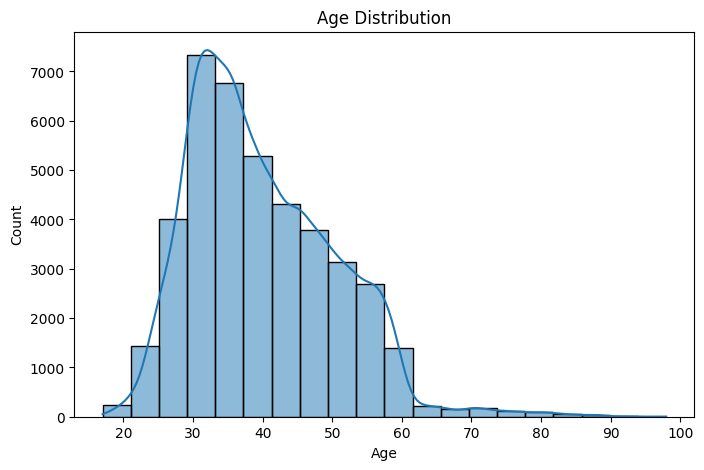

In [ ]:
# Age distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


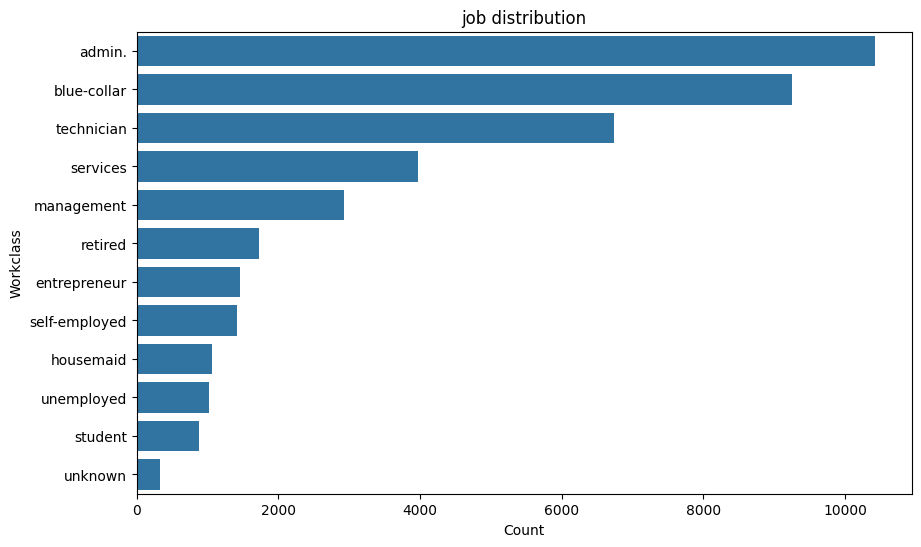

In [ ]:
# Job distribution

plt.figure(figsize=(10,6))
sns.countplot(y=df['job'], order=df['job'].value_counts().index)
plt.title("job distribution")
plt.xlabel("Count")
plt.ylabel("Workclass")
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Balance & Deposit Trends

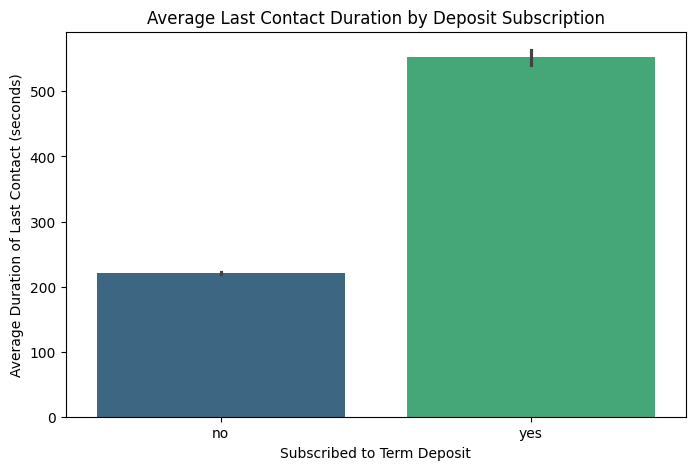

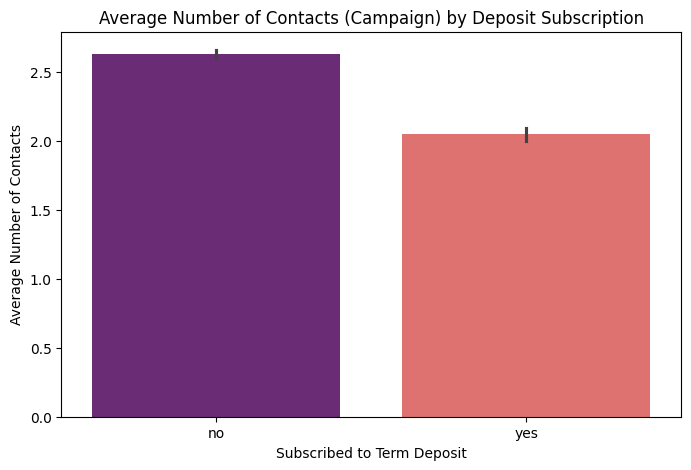

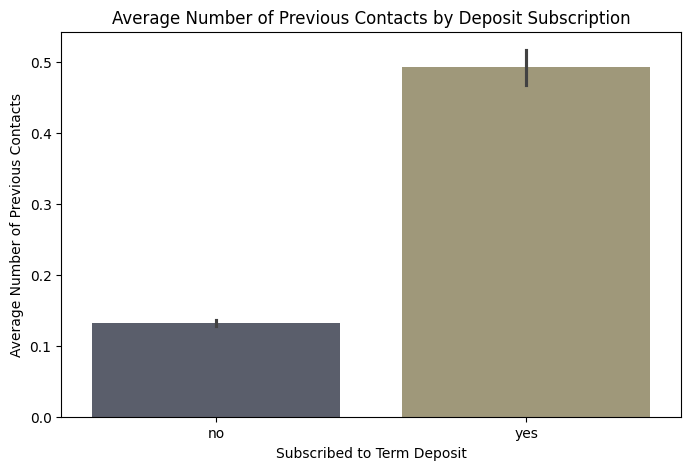

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.copy()
df_plot['subscribed'] = df_plot['y'].map({'no': 0, 'yes': 1})

# Average duration of last contact by deposit subscription
plt.figure(figsize=(8, 5))
sns.barplot(x='y', y='duration', data=df_plot, palette='viridis', hue='y', legend=False)
plt.title('Average Last Contact Duration by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Average Duration of Last Contact (seconds)')
plt.show()



# Average number of contacts during this campaign by deposit subscription
plt.figure(figsize=(8, 5))
sns.barplot(x='y', y='campaign', data=df_plot, palette='magma', hue='y', legend=False)
plt.title('Average Number of Contacts (Campaign) by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Average Number of Contacts')
plt.show()

# Average number of previous contacts by deposit subscription
plt.figure(figsize=(8, 5))
sns.barplot(x='y', y='previous', data=df_plot, palette='cividis', hue='y', legend=False)
plt.title('Average Number of Previous Contacts by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Average Number of Previous Contacts')
plt.show()





## Campaign Effectiveness

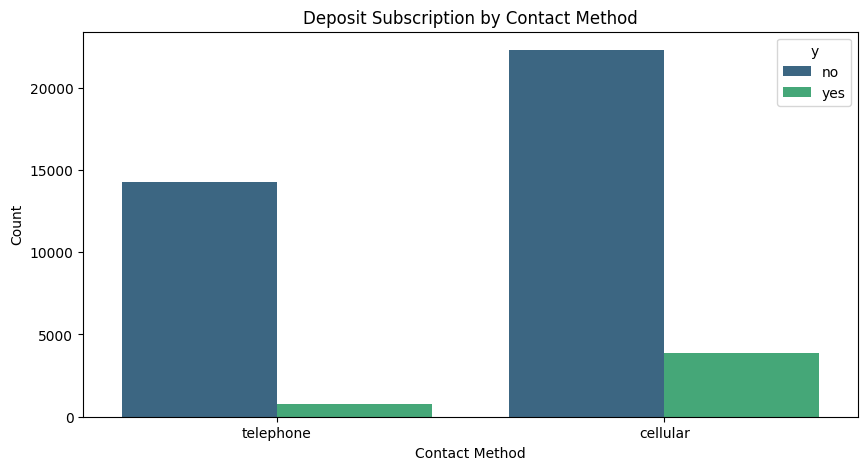

In [ ]:
# Contact method analysis

plt.figure(figsize=(10, 5))
sns.countplot(x='contact', hue='y', data=df, palette='viridis')
plt.title('Deposit Subscription by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Count')
plt.show()



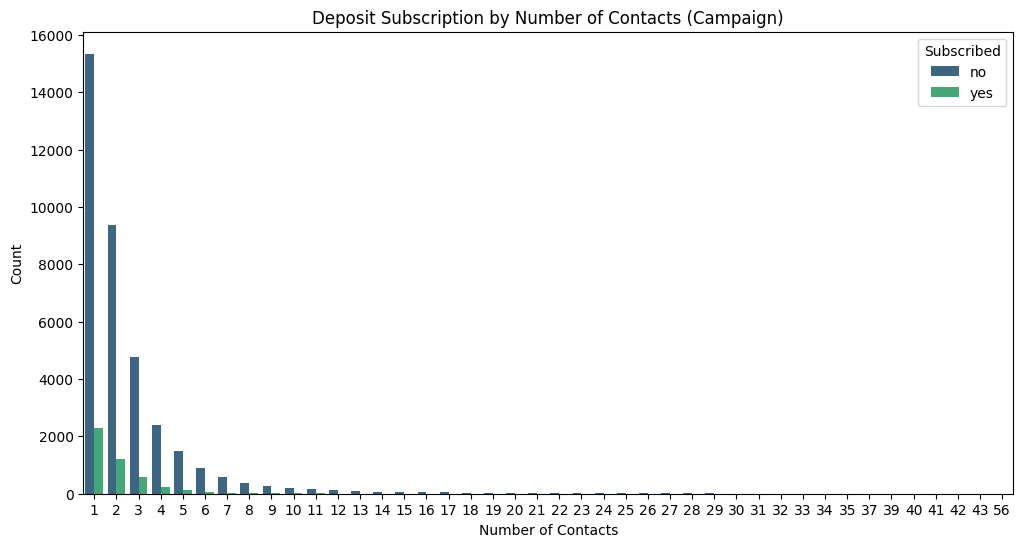

In [ ]:
# Number of contacts vs deposit subscription

plt.figure(figsize=(12, 6))
sns.countplot(x='campaign', hue='y', data=df, palette='viridis')
plt.title('Deposit Subscription by Number of Contacts (Campaign)')
plt.xlabel('Number of Contacts')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.show()


## Correlation Heatmap

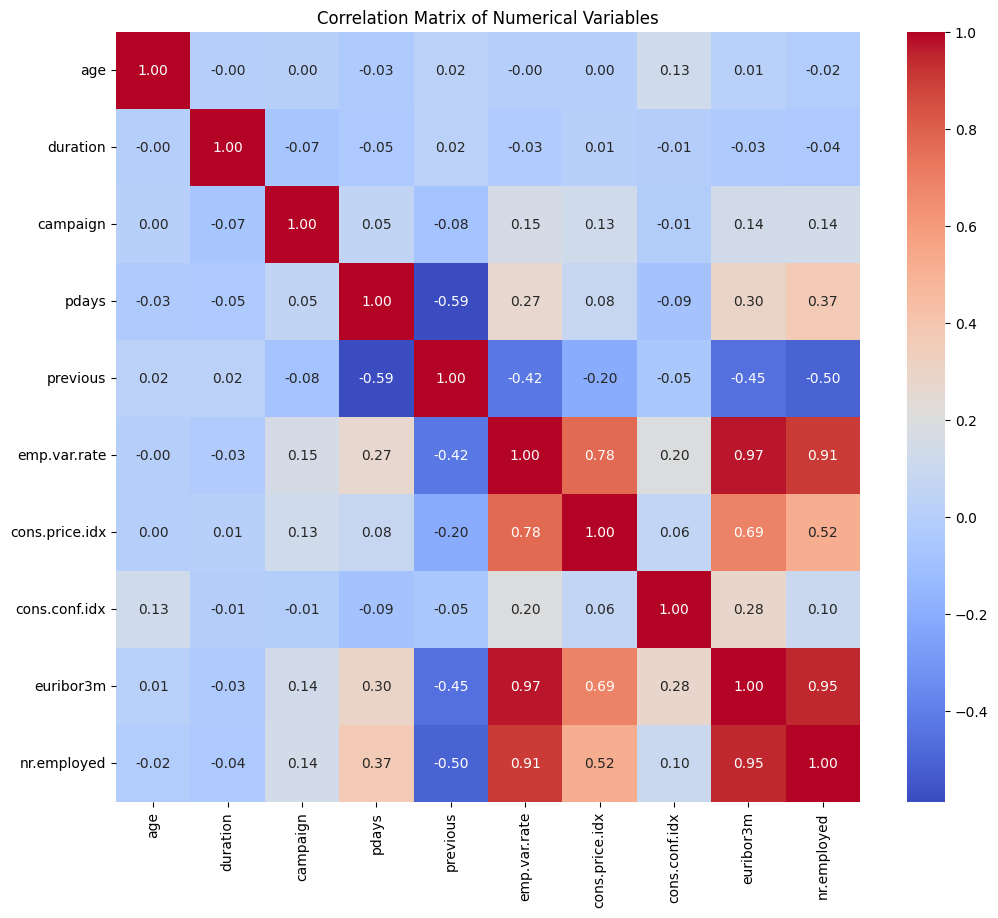

In [ ]:
# Correlation of numerical variables

numerical_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Predictive Modeling (Logistic Regression)

In [ ]:
# encode categorical values
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col])


In [ ]:
#predictions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
y=df['y']
x=df.drop('y',axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.9095654285020636


In [ ]:
# Feature importance
feature_importance = pd.Series(model.coef_[0], index=x.columns)
feature_importance


,0
age,0.008422
job,0.010223
marital,0.024473
education,0.082515
default,-0.027707
housing,0.009280
loan,-0.003183
contact,-0.043043
month,-0.058338
day_of_week,0.023355
